# 1. Which residues can carry a dye?

A FRET experiment starts with a mutation, and the mutation is the part you
cannot take back: a dye on the wrong residue reports on the dye, not on the
protein. The *label score* ([Dimura et al., Nat. Commun. 11, 5394, 2020](https://doi.org/10.1038/s41467-020-19023-1)) ranks
every residue of a structure by how well it would tolerate one, out of terms
that are each a likelihood ratio: how exposed the residue is, whether it looks
like a cysteine already, what secondary structure it sits in, how close the
nearest tryptophan is (a quencher), the local charge, and how conserved it is.

The [Labelizer web application](https://labelizer.org/) implements this
selection workflow. Its score is a starting point for an assay design, not
a substitute for checking the dye volumes that follow.

The terms **multiply**. That matters here, and it is the first thing this
notebook has to deal with.

The molecule is human guanylate-binding protein 1 (hGBP1): a 570-residue
interferon-induced GTPase, a globular G domain with a long helical stalk, and a
large conformational change in that stalk. The workshop carries the change as a
recorded coarse-grained trajectory; its first and last frames are the two
states every number below is computed on.

One thing to be clear about before any number appears. The trajectory topology
is a **monomer**, and its chain labels `A` and `B` are not two protomers: they
are residue ranges 1-151 and 152-570 of one polypeptide, split where the
coarse-grained model was built. A site is called `A63` or `B199` purely by
which range its residue number falls in, and every distance in these notebooks
is intramolecular.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import IMP.bff as bff
import sys, pathlib

# workshop.py sits beside this notebook; nbconvert may be run from anywhere.
for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate)); break
    if (candidate / "doc" / "workshop" / "workshop.py").exists():
        sys.path.insert(0, str(candidate / "doc" / "workshop")); break
import workshop as ws

print("build:", bff.get_build(), "| version:", bff.get_module_version())

N_FRAMES = ws.hgbp1_n_frames()
ENDS = {"start": 0, "end": N_FRAMES - 1}
structures = {state: ws.hgbp1_state(frame) for state, frame in ENDS.items()}
print(f"the recorded transition has {N_FRAMES} frames; "
      f"frame {ENDS['start']} and frame {ENDS['end']} are its two ends")

atoms = [line for line in structures["start"].read_text().splitlines()
         if line.startswith("ATOM")]
ranges = {}
for line in atoms:
    ranges.setdefault(line[21:22], []).append(int(line[22:26]))
for chain, residues in sorted(ranges.items()):
    print(f"  chain {chain}: residues {min(residues)}-{max(residues)}, "
          f"{len(set(residues))} of them")
print(f"  {sum(1 for line in atoms if line[12:16].strip() == 'CB')} of "
      f"{sum(len(set(r)) for r in ranges.values())} residues carry a CB, which is "
      f"what a dye's accessible volume hangs from")

build: imp | version: ab5de21
the recorded transition has 58 frames; frame 0 and frame 57 are its two ends
  chain A: residues 1-151, 151 of them
  chain B: residues 152-570, 419 of them
  544 of 570 residues carry a CB, which is what a dye's accessible volume hangs from


## The change the labels have to report

Before ranking residues it is worth watching what the experiment is supposed to
see. Below is the recorded transition, every fourth frame, animated in the
browser: the G domain stays where it is and the stalk swings out. A pair of
dyes is only worth the mutation if the distance between them is different at
the two ends of that motion, which is the question notebook 2 answers.

If the panel stays blank, Mol* needs internet access from the browser; nothing
else in the notebook depends on it.

In [2]:
frames = ws.hgbp1_frames(every=4)
print(f"{len(frames)} frames in the animation, "
      f"{frames[0].count('ATOM')} atoms each (C-alpha trace)")

ws.show([{
    "title": "hGBP1: the conformational change the labels have to report",
    "structure": ws.morph_pdb(frames),
    "animate_models": True,
    "frame_ms": 300,
    "clouds": [],
}], height=440)

15 frames in the animation, 570 atoms each (C-alpha trace)


## The conservation term, and where its grades come from

The published model carries a conservation term at weight 1. Conservation is
not computed from the structure -- it comes from a multiple alignment, as
ConSurf grades, and it has to exist for the protein in front of you.

For hGBP1 it does, from the second place you look. The paper's own webserver,
[labelizer.org](https://labelizer.org), is asked first over its REST surface
(the same one the `ipynb/example` notebooks drive): it lists the entries it
holds ConSurf grades for and serves the grades file directly. For 1F5N, the
hGBP1 crystal entry, it holds none -- its internal ConSurf job has never
delivered for that entry (an analysis job with the conservation toggle on,
submitted 2026-09-18, terminated with exposure, cysteine and
secondary-structure tables and no conservation). ConSurf-DB, the precomputed
database, has a finished run: 6252 homologues found, 300 in the final
alignment. `ws.hgbp1_consurf_grades()` asks the webserver first, falls
through to the database, downloads once into `_data/`, and writes one atom
per residue of the workshop topology with the normalised grade in the
B-factor column -- exactly the file `labelizer_read_consurf` reads.

One remap on the way in, checked rather than assumed. The grades arrive on
the crystal entry's numbering: 1F5N models residues 7-583 with a disordered
gap at 158-164 -- 570 residues, which the workshop topology numbers 1-570.
The k-th residue of the topology takes the grade of the k-th modelled
position, and the mapping is verified by residue identity before it is used:
all 570 match. That gap is also where the topology's `A`/`B` label boundary
at 151/152 falls -- the split the coarse-grained model inherited from what
the crystal resolved.

In [3]:
paper = bff.labelizer_model_paper()
print("paper model:", [(p.tag, p.weight, p.table or "-") for p in paper])

scores = bff.labelizer_score_structure(str(structures["start"]), paper,
                                       bff.LabelizerOptions(), "")
combined = [s.value for s in scores if s.score_type == "combined"]
print(f"\nwith the paper model and no grades: {len(combined)} residues, "
      f"every score = {np.nanmax(combined):.2f}")

paper model: [('cs', 1, 'N_CS2_Score'), ('se', 1, 'N_SE11_MEAN_SURFACE_DIST'), ('tp', 0, '-'), ('cr', 1, 'C_CR1_Name'), ('ss', 1, 'C_SS1_SS'), ('ce', 0, '-')]

with the paper model and no grades: 570 residues, every score = 0.00


In [4]:
model = paper                          # the full published model, conservation on
grades = ws.hgbp1_consurf_grades()     # fetched once into _data/, reused after

grade_map = bff.labelizer_read_consurf(str(grades))
structure = bff.labelizer_read_structure(str(structures["start"]))
covered = sum(1 for r in structure.residues
              if bff.labelizer_residue_key(r.chain, r.seq_id) in grade_map)
values = np.array(sorted(grade_map.values()))
print(f"grades for {covered}/{len(structure.residues)} residues of the topology, "
      f"{len(set(grade_map.values()))} distinct, "
      f"{values.min():.2f} conserved to {values.max():.2f} variable")


def label_scores(pdb_path):
    '''{(chain, residue): combined score} for one structure, conservation on.'''
    rows = bff.labelizer_score_structure(str(pdb_path), model,
                                         bff.LabelizerOptions(), str(grades))
    return {(r.asym_id, r.seq_id): r.value
            for r in rows if r.score_type == "combined"}


ls = {state: label_scores(path) for state, path in structures.items()}
for state, table in ls.items():
    finite = np.array([v for v in table.values() if np.isfinite(v)])
    print(f"{state:5s} {len(table):5d} residues, score {finite.min():.2f}-{finite.max():.2f}, "
          f"mean {finite.mean():.2f}")

grades for 570/570 residues of the topology, 528 distinct, -1.41 conserved to 3.06 variable
start   570 residues, score 0.00-1.97, mean 1.04
end     570 residues, score 0.00-1.97, mean 1.04


### What the conservation term changes

The same start structure scored with and without the term: x without, y with,
and the colour the ConSurf grade itself -- red conserved, green variable.
Conserved residues sit below the diagonal: the evolutionary record says a
position it is holding is a poor place to force a dye, and the term pushes
such sites down. On this protein the gradient is where the biology says it
should be -- the G-domain core is the conserved part, the stalk that swings
out is the variable one.

top-10 sites with/without conservation: 6 of 10 shared
conservation demotes: B270(1.70) B489(1.57) B312(1.57) B200(1.54)


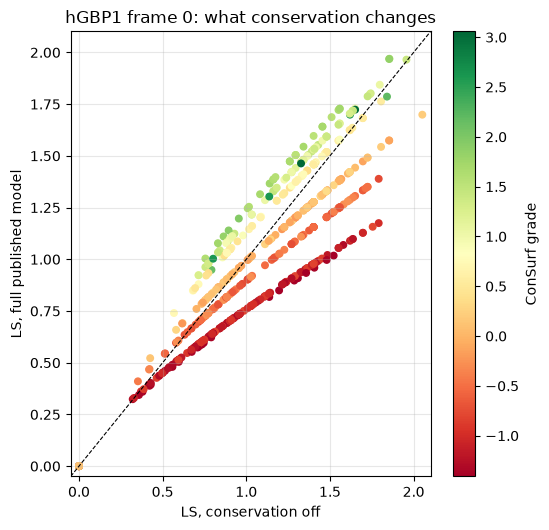

In [5]:
no_cs = bff.LabelizerParameterList()
for parameter in paper:
    if parameter.tag != "cs":
        no_cs.append(parameter)

comb_cs = {bff.labelizer_residue_key(r.asym_id, r.seq_id): r.value
           for r in bff.labelizer_score_structure(
                   str(structures["start"]), model, bff.LabelizerOptions(),
                   str(grades))
           if r.score_type == "combined"}
comb_ncs = {bff.labelizer_residue_key(r.asym_id, r.seq_id): r.value
            for r in bff.labelizer_score_structure(
                    str(structures["start"]), no_cs, bff.LabelizerOptions(), "")
            if r.score_type == "combined"}

keys = sorted(set(comb_cs) & set(comb_ncs), key=lambda k: int(k[1:]))
x = np.array([comb_ncs[k] for k in keys])      # conservation off
y = np.array([comb_cs[k] for k in keys])       # the full published model
g = np.array([grade_map[k] for k in keys])     # the ConSurf grade itself

top_cs = set(sorted(comb_cs, key=comb_cs.get, reverse=True)[:10])
top_ncs = set(sorted(comb_ncs, key=comb_ncs.get, reverse=True)[:10])
print(f"top-10 sites with/without conservation: {len(top_cs & top_ncs)} of 10 shared")
demoted = sorted(top_ncs - top_cs, key=comb_ncs.get, reverse=True)
print("conservation demotes:", " ".join(f"{k}({comb_cs[k]:.2f})" for k in demoted))

fig, ax = plt.subplots(figsize=(5.6, 5.4))
lim = (min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05)
ax.plot(lim, lim, "k--", lw=0.8)
sc = ax.scatter(x, y, c=g, cmap="RdYlGn", s=22)   # red conserved, green variable
fig.colorbar(sc, ax=ax, label="ConSurf grade")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("LS, conservation off")
ax.set_ylabel("LS, full published model")
ax.set_title(f"hGBP1 frame {ENDS['start']}: what conservation changes")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## One number is five numbers

The combined score is the **weighted geometric mean** of the terms, so reading
it alone throws away the reason for it. Two sites can score the same because
one is beautifully exposed and barely cysteine-like, and the other the other
way round -- and those two sites behave differently when you put a dye on them.

`labelizer_score_structure` returns every term, not just the combination: one
row per (residue, score type). Here they are for the same structure.

In [6]:
def components(pdb_path):
    '''{(chain, residue): {score type: value}} -- every term, not just the total.'''
    rows = bff.labelizer_score_structure(str(pdb_path), model,
                                         bff.LabelizerOptions(), str(grades))
    table = {}
    for row in rows:
        table.setdefault((row.asym_id, row.seq_id), {})[row.score_type] = row.value
    return table


parts = {state: components(path) for state, path in structures.items()}
TERMS = ["solvent_exposure", "cysteine_resemblance", "secondary_structure",
         "conservation", "charge_environment", "tryptophan_proximity"]
TAGS = {"solvent_exposure": "se", "cysteine_resemblance": "cr",
        "secondary_structure": "ss", "conservation": "cs",
        "charge_environment": "ce", "tryptophan_proximity": "tp"}
weights = {p.tag: p.weight for p in model}
print("term weights in this model:", {TAGS[t]: weights[TAGS[t]] for t in TERMS})

best = max(((values["combined"], key) for key, values in parts["start"].items()
            if np.isfinite(values["combined"])))[1]
print(f"\nthe best-scoring residue of the start structure, term by term: "
      f"{best[0]}{best[1]}")
site = parts["start"][best]
for term in TERMS + ["combined"]:
    print(f"  {term:24s} {site[term]:6.3f}")

term weights in this model: {'se': 1, 'cr': 1, 'ss': 1, 'cs': 1, 'ce': 0, 'tp': 0}

the best-scoring residue of the start structure, term by term: B199
  solvent_exposure          2.973
  cysteine_resemblance      1.578
  secondary_structure       1.362
  conservation              2.355
  charge_environment        0.482
  tryptophan_proximity      1.000
  combined                  1.969


### The combination, checked

Weight 1 on solvent exposure, cysteine resemblance, secondary structure and
conservation; weight 0 on charge environment and tryptophan proximity, so
those two are computed and reported but do not enter. The geometric mean of
the four that count reproduces the combined score exactly -- which is also
why a single term at zero takes the whole site to zero, as conservation did
above when its grades were missing.

In [7]:
used = ["solvent_exposure", "cysteine_resemblance", "secondary_structure",
        "conservation"]
show_sites = [key for _, key in sorted(
    ((values["combined"], key) for key, values in parts["start"].items()
     if np.isfinite(values["combined"])), reverse=True)[:4]]

print(f"{'site':>6} {'se':>7} {'cr':>7} {'ss':>7} {'cs':>7} {'geo.mean':>9} {'combined':>9}")
for chain, resi in show_sites:
    values = parts["start"][(chain, resi)]
    geometric = np.prod([values[term] for term in used]) ** (1.0 / len(used))
    print(f"{chain + str(resi):>6} " + " ".join(f"{values[t]:7.3f}" for t in used)
          + f" {geometric:9.3f} {values['combined']:9.3f}")

  site      se      cr      ss      cs  geo.mean  combined
  B199   2.973   1.578   1.362   2.355     1.969     1.969
  B457   2.973   2.185   0.981   2.355     1.968     1.968
  B383   1.978   3.864   0.981   1.989     1.965     1.965
   A12   2.973   1.435   1.362   1.989     1.844     1.844


### Every term along the sequence

The terms disagree, and where they disagree is where the choice is actually
made. Solvent exposure is the one that moves between the two ends of the
transition -- it is a property of the surface, and the surface is what the
stalk motion rearranges. Cysteine resemblance is a property of the sequence
alone and does not move at all; secondary structure moves only where the
trajectory melts or forms a turn.

Conservation does not move either, for the same reason: none of it comes from
the structure, so the two frames carry identical values. What varies is where
it sits along the chain -- low over the G-domain core the evolution is
holding, rising along the stalk out to the variable C-terminus, which is the
gradient the figure above showed as colour.

Tryptophan proximity is worth a word, because its panel is a flat line at 1.
That is the term declining to say anything, not the protein having no
tryptophans -- it has four in this model. In the published parameter list `tp`
carries weight 0 and no lookup table (printed as `-` above), so it returns the
neutral ratio everywhere. Charge environment, also at weight 0, does have a
table and does vary; it is reported and ignored.

The x axis runs over the whole polypeptide, 1 to 570, across the `A`/`B` label
boundary at residue 151, because the label boundary is bookkeeping and the
chain is one chain.

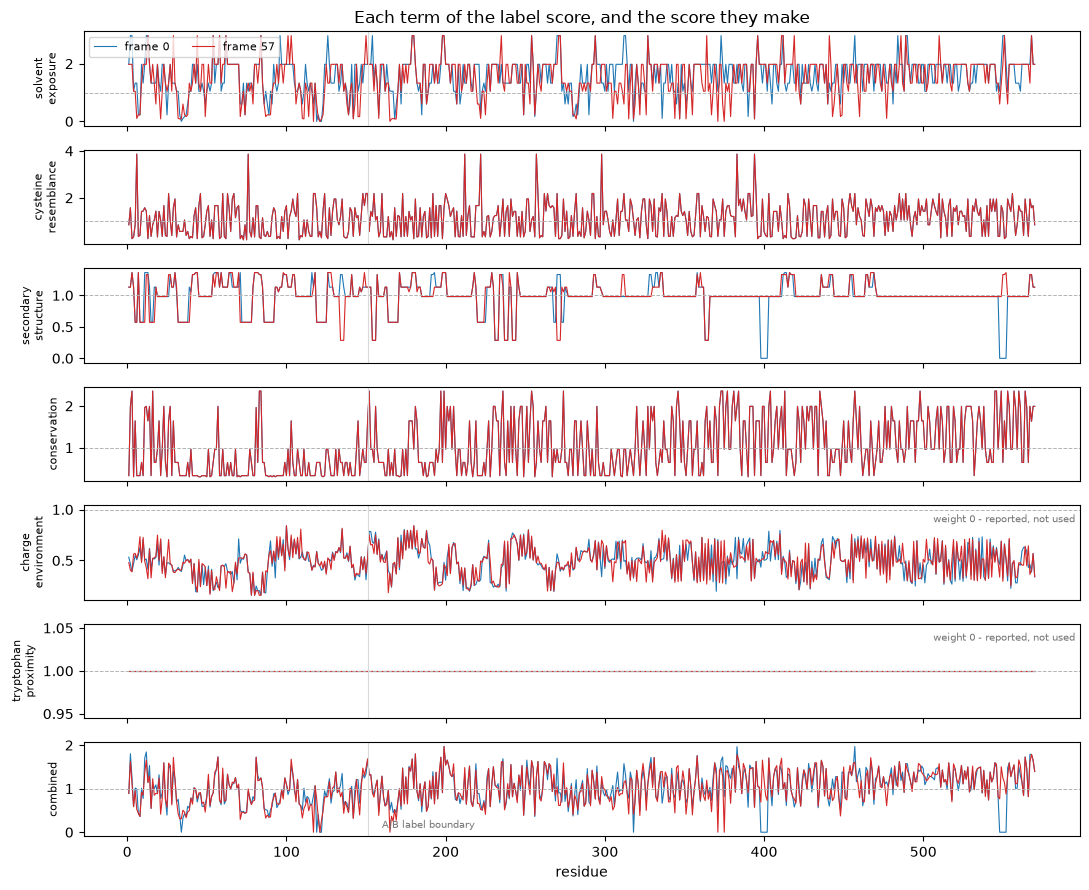

In [8]:
order = sorted(parts["start"], key=lambda key: (key[1], key[0]))
residues = [resi for _chain, resi in order]

fig, axes = plt.subplots(len(TERMS) + 1, 1, figsize=(11, 9), sharex=True)
for ax, term in zip(axes, TERMS + ["combined"]):
    for state, colour in (("start", "C0"), ("end", "C3")):
        values = [parts[state].get(key, {}).get(term, np.nan) for key in order]
        ax.plot(residues, values, lw=0.8, color=colour,
                label=f"frame {ENDS[state]}" if term == TERMS[0] else None)
    weight = 1 if term == "combined" else weights[TAGS[term]]
    ax.axhline(1.0, color="0.7", lw=0.7, ls="--")
    ax.axvline(151.5, color="0.85", lw=0.8)
    ax.set_ylabel(term.replace("_", "\n"), fontsize=8)
    ax.text(0.995, 0.82, "weight 0 - reported, not used" if weight == 0 else "",
            transform=ax.transAxes, ha="right", fontsize=7.5, color="0.45")
axes[0].legend(fontsize=8, ncol=2, loc="upper left")
axes[-1].annotate("A|B label boundary", xy=(151.5, 0), xytext=(160, 0.1),
                  fontsize=7, color="0.45")
axes[-1].set_xlabel("residue")
axes[0].set_title("Each term of the label score, and the score they make")
fig.tight_layout()
plt.show()

### What the terms are computed from

Underneath the likelihood ratios are plain structural quantities, and it is
worth seeing them once: the secondary structure assignment, how buried the
residue is, and how much of its surface is reachable. A site chosen against
the score is a site chosen against these.

DSSP: -=92, B=6, E=52, G=15, H=315, I=10, S=41, T=39
residue depth 1.48 - 4.35 A
relative solvent accessibility 0.00 - 0.94


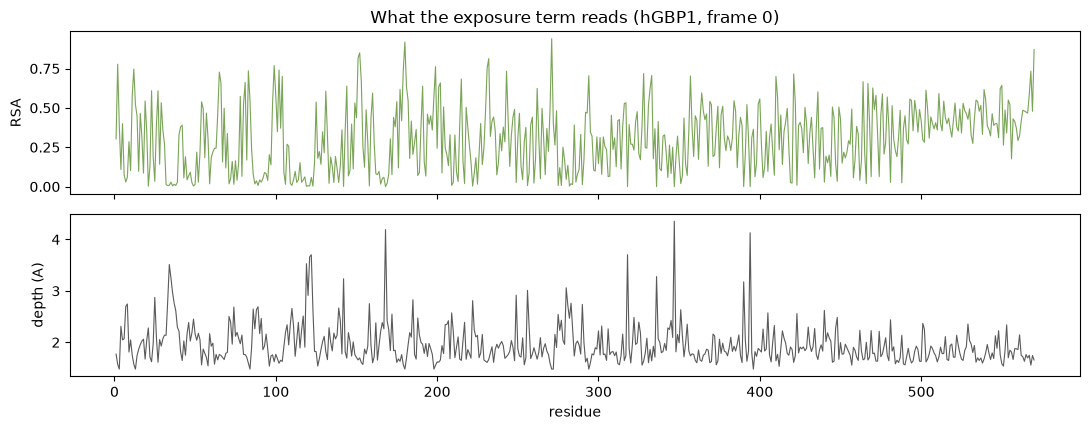

In [9]:
structure = bff.labelizer_read_structure(str(structures["start"]))
secondary = bff.labelizer_dssp(structure)
depth = np.asarray(bff.labelizer_residue_depth(structure, 1.4, 590))
rsa = np.asarray(bff.labelizer_relative_solvent_accessibility(
    structure, bff.LABELIZER_MAXASA_WILKE, 1.4, 590))

counts = {s: secondary.count(s) for s in sorted(set(secondary))}
print("DSSP:", ", ".join(f"{k or '-'}={v}" for k, v in counts.items()))
print(f"residue depth {depth.min():.2f} - {depth.max():.2f} A")
print(f"relative solvent accessibility {rsa.min():.2f} - {rsa.max():.2f}")

seq = [r.seq_id for r in structure.residues]

fig, (ax, bx) = plt.subplots(2, 1, figsize=(11, 4.4), sharex=True)
ax.plot(seq, rsa, lw=0.8, color="#7aa457")
ax.set_ylabel("RSA")
ax.set_title(f"What the exposure term reads (hGBP1, frame {ENDS['start']})")
bx.plot(seq, depth, lw=0.8, color="#5a5a5a")
bx.set_ylabel("depth (A)"); bx.set_xlabel("residue")
fig.tight_layout()
plt.show()

### Which term decided

For each candidate, the term furthest from 1 is the one that made the
decision -- above 1 it argued for the site, below 1 against. A site carried by
a single strong term is a more fragile choice than one every term likes.

In [10]:
top_by_score = sorted(
    ((values["combined"], key) for key, values in parts["start"].items()
     if np.isfinite(values["combined"])), reverse=True)[:10]

print(f"{'site':>6} {'combined':>8}  {'strongest for':>30}  {'strongest against':>30}")
for score, (chain, resi) in top_by_score:
    values = parts["start"][(chain, resi)]
    scored = {term: values[term] for term in used}
    strongest = max(scored, key=lambda t: scored[t])
    weakest = min(scored, key=lambda t: scored[t])
    print(f"{chain + str(resi):>6} {score:8.2f}  "
          f"{strongest + f' {scored[strongest]:.2f}':>30}  "
          f"{weakest + f' {scored[weakest]:.2f}':>30}")

  site combined                   strongest for               strongest against
  B199     1.97           solvent_exposure 2.97        secondary_structure 1.36
  B457     1.97           solvent_exposure 2.97        secondary_structure 0.98
  B383     1.97       cysteine_resemblance 3.86        secondary_structure 0.98
   A12     1.84           solvent_exposure 2.97        secondary_structure 1.36
    A2     1.80           solvent_exposure 2.97        secondary_structure 1.13
  B181     1.80               conservation 1.99        secondary_structure 1.36
  B567     1.79               conservation 1.99        secondary_structure 1.33
  B568     1.79           solvent_exposure 2.97        secondary_structure 1.33
  B358     1.76       cysteine_resemblance 2.19        secondary_structure 1.36
   A57     1.73               conservation 1.99        secondary_structure 1.36


## What the transition does to the score

On a homodimer there is a free consistency check at this point: the two
protomers are the same sequence in the same fold, so they should score the same
residue alike, and a site where they disagree is a site where the structure says
they really differ. hGBP1 is a monomer and has no such check. The question that
replaces it is the one the experiment cares about anyway: **does a site stay
labelable while the protein moves?**

Most of the protein does not care. But the stalk motion buries some residues
and exposes others, and a residue that is a fine site at one end of the
transition and unlabelable at the other cannot be used to watch the transition,
because half the time there would be nothing there to watch with.

In [11]:
shared = [key for key in ls["start"] if key in ls["end"]]
a = np.array([ls["start"][key] for key in shared])
b = np.array([ls["end"][key] for key in shared])
good = np.isfinite(a) & np.isfinite(b)
delta = np.abs(a[good] - b[good])
keys = [key for key, ok in zip(shared, good) if ok]

print(f"{good.sum()} residues scored at both ends")
print(f"mean |change|: {delta.mean():.3f}, largest {delta.max():.3f}")
print(f"moved by more than 0.25: {(delta > 0.25).sum()};  by more than 0.5: "
      f"{(delta > 0.5).sum()}")

THRESHOLD = 1.5
up = sum(1 for v in a[good] if v >= THRESHOLD)
down = sum(1 for v in b[good] if v >= THRESHOLD)
both = sum(1 for v, w in zip(a[good], b[good]) if v >= THRESHOLD and w >= THRESHOLD)
print(f"\nat or above {THRESHOLD}: {up} at the start, {down} at the end, "
      f"{both} at both -- and only those {both} are usable")

print(f"\n{'site':>6} {'start':>7} {'end':>7} {'change':>8}")
for index in np.argsort(-delta)[:8]:
    chain, resi = keys[index]
    print(f"{chain + str(resi):>6} {a[good][index]:7.2f} {b[good][index]:7.2f} "
          f"{b[good][index] - a[good][index]:+8.2f}")

570 residues scored at both ends
mean |change|: 0.108, largest 1.657
moved by more than 0.25: 54;  by more than 0.5: 22

at or above 1.5: 69 at the start, 77 at the end, 53 at both -- and only those 53 are usable

  site   start     end   change
  B399    0.00    1.66    +1.66
  B549    0.00    1.50    +1.50
  B550    0.00    1.25    +1.25
  B400    0.00    1.22    +1.22
  B551    0.00    1.14    +1.14
  B552    0.00    0.88    +0.88
  B401    0.00    0.84    +0.84
  A117    0.84    0.00    -0.84


## The score along the sequence

The useful sites are the peaks: exposed, unstructured enough, no tryptophan
next door. The two ends mostly agree -- the label score is about the local
environment, and most of the fold is unchanged -- but not everywhere, and the
places where the two curves part company are the stalk and the termini.

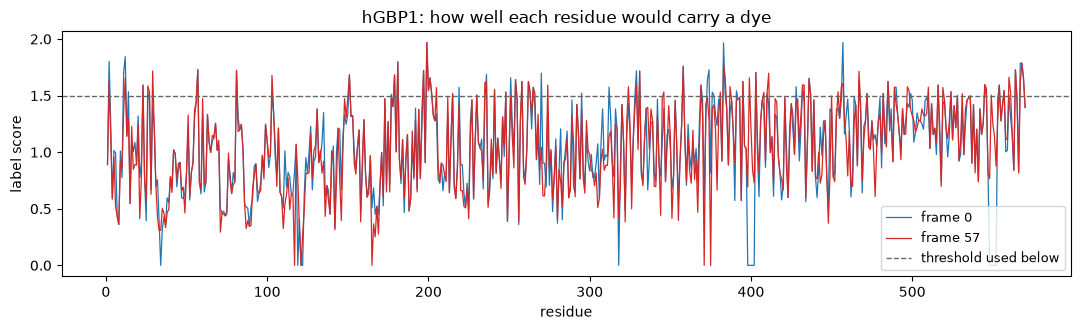

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.4))
for state, colour in (("start", "C0"), ("end", "C3")):
    values = [ls[state].get(key, np.nan) for key in order]
    ax.plot(residues, values, lw=0.9, color=colour,
            label=f"frame {ENDS[state]}")
ax.axhline(THRESHOLD, color="0.4", ls="--", lw=1, label="threshold used below")
ax.set_xlabel("residue"); ax.set_ylabel("label score")
ax.set_title("hGBP1: how well each residue would carry a dye")
ax.legend(fontsize=9); fig.tight_layout()
plt.show()

## Candidate sites

A candidate has to clear the threshold **at both ends** of the transition -- a
site that is only labelable in one of them cannot report on the change between
them -- and candidates too close together in sequence are redundant, because
they see the same neighbourhood. What comes out is the shortlist the next
notebooks work with.

In [13]:
MIN_SEPARATION = 10

def candidates(threshold=THRESHOLD, min_separation=MIN_SEPARATION):
    both = []
    for key, value in ls["start"].items():
        if not np.isfinite(value) or value < threshold:
            continue
        other = ls["end"].get(key, np.nan)
        if np.isfinite(other) and other >= threshold:
            both.append((key, min(value, other)))
    both.sort(key=lambda row: -row[1])
    chosen = []
    for (chain, resi), value in both:
        if all(abs(resi - taken) >= min_separation for (_c, taken), _v in chosen):
            chosen.append(((chain, resi), value))
    return chosen


sites = candidates()
print(f"{len(sites)} candidate sites (score >= {THRESHOLD} at both ends, "
      f">= {MIN_SEPARATION} residues apart)\n")
print(f"{'site':>6} {'start':>7} {'end':>7}")
for (chain, resi), _ in sites[:15]:
    print(f"{chain + str(resi):>6} {ls['start'][(chain, resi)]:>7.2f} "
          f"{ls['end'][(chain, resi)]:>7.2f}")

26 candidate sites (score >= 1.5 at both ends, >= 10 residues apart)

  site   start     end
  B199    1.97    1.97
  B181    1.80    1.80
  B568    1.79    1.79
  B383    1.97    1.78
  B358    1.76    1.75
   A57    1.73    1.73
   A81    1.72    1.72
  B331    1.72    1.72
  B403    1.70    1.70
  A151    1.68    1.68
   A12    1.84    1.66
  B436    1.65    1.65
  B254    1.64    1.64
  B467    1.64    1.71
    A2    1.80    1.63


## What a candidate looks like

The score is a number about a neighbourhood, so it is worth looking at the
neighbourhood. Below, the two best candidates are drawn on the start structure
as the accessible volume a dye would occupy there -- which is also the subject
of notebook 3. The camera spins, because a still picture of a dye cloud hides
half of it behind the protein.

In [14]:
top = [key for key, _ in sites[:2]]
print("showing sites", [f"{c}{r}" for c, r in top])

panel = ws.site_panel(
    "start",
    [{"chain": top[0][0], "resi": top[0][1], "colour": ws.DONOR_COLOUR},
     {"chain": top[1][0], "resi": top[1][1], "dye": "Alexa647",
      "colour": ws.ACCEPTOR_COLOUR}],
    title=f"hGBP1 frame {ENDS['start']} - sites "
          f"{top[0][0]}{top[0][1]} and {top[1][0]}{top[1][1]}",
    pdb_path=structures["start"],
)
panel["spin"] = True
ws.show([panel])

showing sites ['B199', 'B181']


### The score on the fold

The same numbers, painted onto the structure: blue is a poor site, red a good
one. This is the picture worth taking into the lab -- the good sites are on the
outside of the stalk helices and in the loops, and the core of the G domain is
blue because a dye there has nowhere to sit.

The score goes into the B-factor column, which is how any viewer can colour by
it; `score_coloured_pdb` writes that file and Mol*'s uncertainty theme reads it.
The two panels are the two ends of the transition, so the places where the
colours differ are the places the previous section counted.

In [15]:
panels = []
for state in ("start", "end"):
    combined = {key: values["combined"] for key, values in parts[state].items()}
    panels.append({
        "title": f"hGBP1 frame {ENDS[state]} - coloured by label score "
                 f"(blue poor, red good)",
        "structure": ws.score_coloured_pdb(structures[state], combined),
        "colour_by": "score",
        "clouds": [],
    })
ws.show(panels, height=460)

## What a real experiment on this protein used

Everything above is computed from structures. hGBP1 also has a *measured* FRET
network, and the workshop carries it: `ws.hgbp1_network()` returns the published
`fps.json` with its labelling positions and its measured distances, each with
its own asymmetric error bars.

It does not map onto the structures used here, and the reason is worth stating
rather than glossing. Those measurements were made on the hGBP1 **dimer**: the
positions are named on two protomers `A` and `B` that really are two protomers,
they reach residue 577 -- past the 570 this topology has -- three of them sit on
a fused eGFP or mCherry and are numbered further out still, and the `chi2` sets
split the data into an intra-protomer set (`577_577`) and an inter-protomer one.
The trajectory above is a monomer whose `A`/`B` labels are residue ranges.
Feeding one into the other would silently pair residues that are not the
residues the experiment labelled.

So the network is shown here for what it is -- the scale of a real experiment
on this molecule -- and it is notebooks 5 and 7, which work on the dimer, that
actually use it.

In [16]:
network = ws.hgbp1_network()
positions = network["positions"]
print(f"{len(positions)} labelling positions, {len(network['distances'])} measured "
      f"distances, chi2 sets {network['chi2_sets']}")
print("positions:", ", ".join(sorted(positions)))

native = sorted({entry["residue_seq_number"] for key, entry in positions.items()
                 if "_" not in key})
fusion = sorted({entry["residue_seq_number"] for key, entry in positions.items()
                 if "_" in key})
last = max(max(r) for r in ranges.values())
print(f"\nresidues labelled on the protein itself: "
      f"{', '.join(str(n) for n in native)}")
print(f"on the fused fluorescent proteins: {', '.join(str(n) for n in fusion)}")
print(f"the trajectory topology stops at {last}, so "
      f"{sum(1 for n in native if n > last)} of the native positions and all "
      f"{len(fusion)} fusion positions have no residue to sit on here")

first = network["distances"][sorted(network["distances"])[0]]
print(f"\none measured distance, as the file carries it:")
for field in ("distance", "error_neg", "error_pos", "Forster_radius",
              "distance_type", "position1_name", "position2_name"):
    if field in first:
        print(f"  {field:16s} {first[field]}")

18 labelling positions, 68 measured distances, chi2 sets ['577_577', 'inter']
positions: A18F, A254F, A344F, A481F, A496F, A525F, A540F, A577F, A577F_eGFP, A577F_mCh, B18F, B254F, B344F, B481F, B496F, B525F, B540F, B577F

residues labelled on the protein itself: 18, 254, 344, 481, 496, 525, 540, 577
on the fused fluorescent proteins: 815, 825
the trajectory topology stops at 570, so 1 of the native positions and all 2 fusion positions have no residue to sit on here

one measured distance, as the file carries it:
  distance         61
  error_neg        2
  error_pos        2
  Forster_radius   52
  distance_type    RDAMean
  position1_name   A18F
  position2_name   B18F


## Next

Notebook 2 turns this shortlist into pairs: which two of these sites, measured
together, would actually report on the stalk motion animated at the top.
Notebook 3 turns a site into a *volume* and a pair of sites into a distance.

The homodimer question -- which **sites** to mutate, given that one mutation
labels both protomers and every pair it implies comes for free -- does not
arise for hGBP1's monomer; it is worked through on BmrA in
`05_site_selection_homodimer.ipynb`.